# Worksheet 5 — CNN Image Classification from Scratch

In [1]:
import zipfile
import os

with zipfile.ZipFile('/content/FruitinAmazon.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/fruits')

os.listdir('/content/fruits')

['FruitinAmazon']

In [2]:
test_dir = '/content/fruits/FruitinAmazon/test'
print(os.listdir(test_dir))

['acai', 'cupuacu', 'graviola', 'pupunha', 'tucuma', 'guarana']


In [3]:
for cls in os.listdir(test_dir):
    count = len(os.listdir(os.path.join(test_dir, cls)))
    print(f"{cls}: {count} images")

acai: 5 images
cupuacu: 5 images
graviola: 5 images
pupunha: 5 images
tucuma: 5 images
guarana: 5 images


In [4]:
import os

train_dir = '/content/fruits/FruitinAmazon/train'
classes = os.listdir(train_dir)
print(classes)

['acai', 'cupuacu', 'graviola', 'pupunha', 'tucuma', 'guarana']


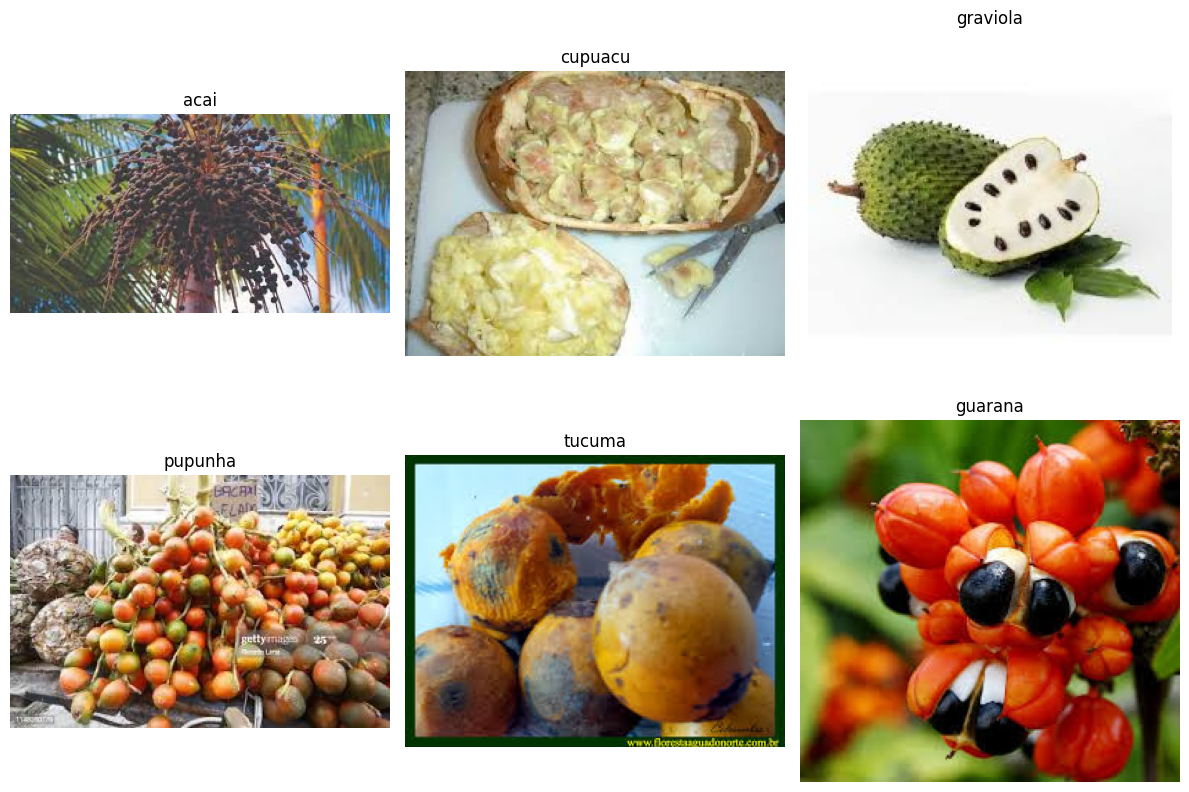

In [5]:
import matplotlib.pyplot as plt
import random
from PIL import Image

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, cls in enumerate(classes):
    cls_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(cls)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [6]:
from PIL import Image
import os

corrupted = []

for cls in classes:
    cls_path = os.path.join(train_dir, cls)
    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        try:
            img = Image.open(img_path)
            img.verify()
        except (IOError, SyntaxError):
            corrupted.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if len(corrupted) == 0:
    print("No corrupted images found.")

No corrupted images found.


In [7]:
import tensorflow as tf

img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

In [8]:
rescale = tf.keras.layers.Rescaling(1./255)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.


In [9]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [10]:
num_classes = len(classes)
print(num_classes)

6


In [11]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(img_height, img_width, 3)),
    tf.keras.layers.MaxPooling2D((2,2), strides=2),
    tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2), strides=2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,416,774 (32.11 MB)

 Trainable params: 8,416,774 (32.11 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_loss', mode='min')
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    train_ds,
    epochs=250,
    validation_data=val_ds,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.1042 - loss: 2.3840

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 523ms/step - accuracy: 0.1250 - loss: 2.8508 - val_accuracy: 0.0000e+00 - val_loss: 2.7121
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.2292 - loss: 2.4290

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 500ms/step - accuracy: 0.2500 - loss: 2.2277 - val_accuracy: 0.8333 - val_loss: 1.5662
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 382ms/step - accuracy: 0.3611 - loss: 1.6771 - val_accuracy: 0.0556 - val_loss: 1.6806
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.3351 - loss: 1.4145

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 435ms/step - accuracy: 0.3333 - loss: 1.3861 - val_accuracy: 0.4444 - val_loss: 1.3930
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.6383 - loss: 1.1238

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 452ms/step - accuracy: 0.6806 - loss: 1.1193 - val_accuracy: 0.6667 - val_loss: 1.1158
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step - accuracy: 0.5845 - loss: 1.0198

...

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 436ms/step - accuracy: 0.8472 - loss: 0.3941 - val_accuracy: 0.7778 - val_loss: 0.6120
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 366ms/step - accuracy: 0.9444 - loss: 0.2049 - val_accuracy: 0.5000 - val_loss: 1.4202
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 405ms/step - accuracy: 0.9444 - loss: 0.1961 - val_accuracy: 0.8333 - val_loss: 0.7059
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 403ms/step - accuracy: 1.0000 - loss: 0.0834 - val_accuracy: 0.8333 - val_loss: 0.7278
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.9497 - loss: 0.1313

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 470ms/step - accuracy: 0.9583 - loss: 0.1211 - val_accuracy: 0.8333 - val_loss: 0.5065
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 569ms/step - accuracy: 1.0000 - loss: 0.0240 - val_accuracy: 0.8333 - val_loss: 0.6669
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 375ms/step - accuracy: 0.9861 - loss: 0.0461 - val_accuracy: 0.8333 - val_loss: 0.6590
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 1.0000 - loss: 0.0217

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 473ms/step - accuracy: 1.0000 - loss: 0.0206 - val_accuracy: 0.7778 - val_loss: 0.4636
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 369ms/step - accuracy: 1.0000 - loss: 0.0078 - val_accuracy: 0.8889 - val_loss: 0.5225
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 405ms/step - accuracy: 1.0000 - loss: 0.0097 - val_accuracy: 0.8889 - val_loss: 0.5670
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 1.0000 - loss: 0.0050

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 476ms/step - accuracy: 1.0000 - loss: 0.0049 - val_accuracy: 0.8889 - val_loss: 0.4348
Epoch 20/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 1.0000 - loss: 0.0025

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 596ms/step - accuracy: 1.0000 - loss: 0.0026 - val_accuracy: 0.8333 - val_loss: 0.4240
Epoch 21/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 571ms/step - accuracy: 1.0000 - loss: 0.0025 - val_accuracy: 0.8333 - val_loss: 0.4732
Epoch 22/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 408ms/step - accuracy: 1.0000 - loss: 0.0022 - val_accuracy: 0.8333 - val_loss: 0.5310
Epoch 23/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 372ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.8333 - val_loss: 0.5604
Epoch 24/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 382ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 0.8333 - val_loss: 0.5610
Epoch 25/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 405ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 0.8333 - val_loss: 0.5513
Epoch 26/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 412ms/step - accuracy: 1.0000 - loss: 7.9110e-04 - val_accuracy: 0.8333 - val_loss: 0.5391
Epoch 27/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 396ms/step - accuracy: 1.0000 - loss: 6.8261e-04 - val_accuracy: 0.8333 

In [14]:
test_dir = '/content/fruits/FruitinAmazon/test'

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False
)

test_ds = test_ds.map(lambda x, y: (rescale(x), y))

Found 30 files belonging to 6 classes.


In [15]:
loss, accuracy = model.evaluate(test_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.6667 - loss: 1.4339
Test Loss: 1.4339
Test Accuracy: 0.6667


In [16]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

print(classification_report(y_true, y_pred, labels=list(range(len(classes))), target_names=classes))

              precision    recall  f1-score   support

        acai       1.00      0.60      0.75         5
     cupuacu       0.71      1.00      0.83         5
    graviola       0.50      1.00      0.67         5
     pupunha       0.75      0.60      0.67         5
      tucuma       0.75      0.60      0.67         5
     guarana       0.50      0.20      0.29         5

    accuracy                           0.67        30
   macro avg       0.70      0.67      0.64        30
weighted avg       0.70      0.67      0.64        30



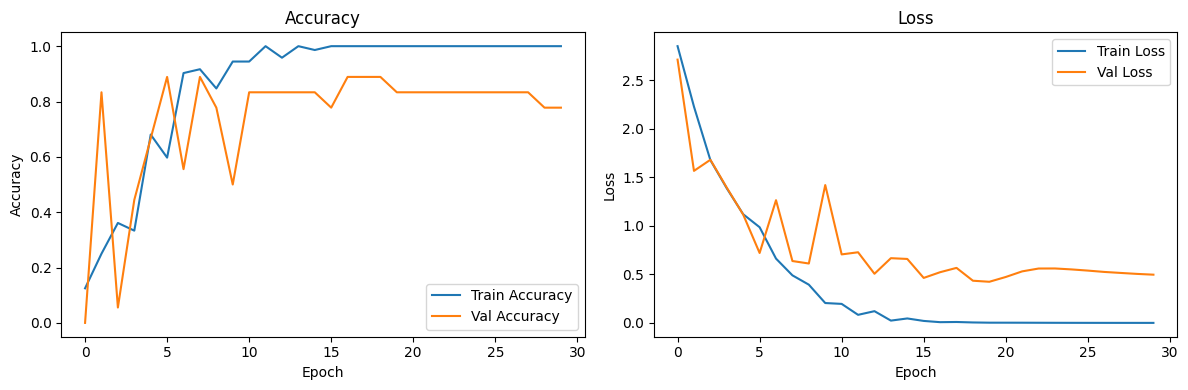

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [18]:
from tensorflow.keras import layers
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    BatchNormalization, Dropout, Activation
)
from tensorflow.keras.models import Sequential

# Image size changed to 224x224 as per worksheet 6
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = len(classes)

In [19]:
# Re-load datasets at 224x224 for worksheet 6
from tensorflow import keras

train_ds_w6, val_ds_w6 = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)

for images, labels in train_ds_w6.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.
Images shape: (32, 224, 224, 3)
Labels shape: (32,)


In [20]:
# Data Augmentation — using keras.Sequential (New API, no Lambda wrapper)
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
]

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

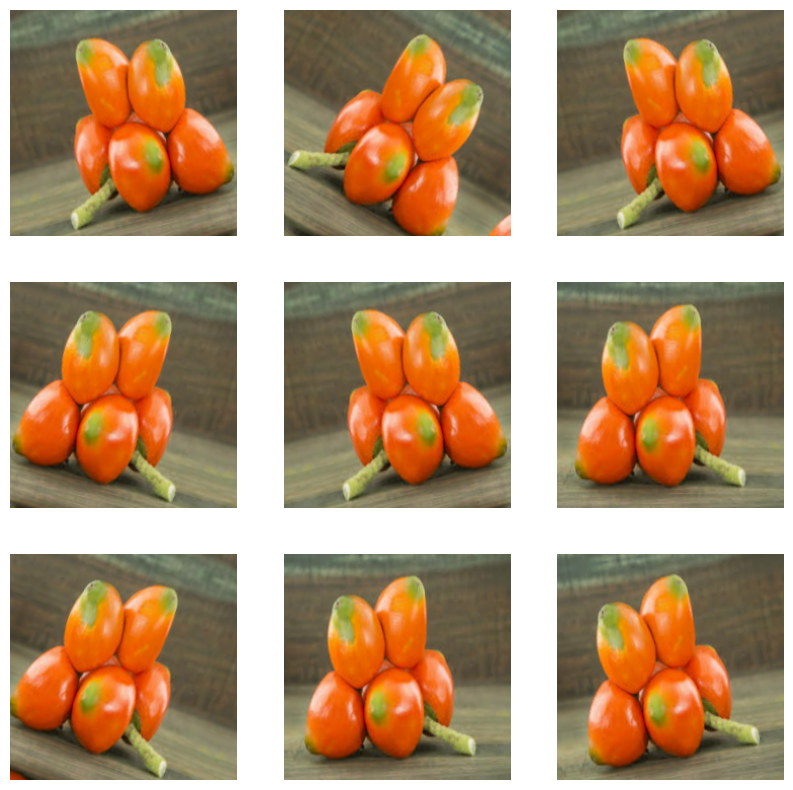

In [21]:
# Visualise augmented images
import numpy as np

plt.figure(figsize=(10, 10))
for images, _ in train_ds_w6.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(augmented_images[0]).astype("uint8"))
        plt.axis("off")

In [22]:

w6_model = Sequential([

    layers.Lambda(data_augmentation, input_shape=(224, 224, 3)),

    layers.Rescaling(1./255),

    Conv2D(32, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(256, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),


    Flatten(),

    Dense(512, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(256, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(128, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(64, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),


    Dense(NUM_CLASSES, activation='softmax')
])

w6_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             

 Total params: 26,257,670 (100.17 MB)

 Trainable params: 26,254,790 (100.15 MB)

 Non-trainable params: 2,880 (11.25 KB)

In [23]:
w6_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

w6_checkpoint = ModelCheckpoint(
    filepath='best_w6_cnn_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)
w6_early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_w6 = w6_model.fit(
    train_ds_w6,
    epochs=50,
    validation_data=val_ds_w6,
    callbacks=[w6_checkpoint, w6_early_stop]
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1157 - loss: 2.4114
Epoch 1: val_accuracy improved from None to 0.05556, saving model to best_w6_cnn_model.keras

Epoch 1: finished saving model to best_w6_cnn_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step - accuracy: 0.0972 - loss: 2.4501 - val_accuracy: 0.0556 - val_loss: 1.8505
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1696 - loss: 2.2877
Epoch 2: val_accuracy did not improve from 0.05556
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.1806 - loss: 2.3210 - val_accuracy: 0.0556 - val_loss: 1.8276
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2240 - loss: 2.1048
Epoch 3: val_accuracy improved from 0.05556 to 0.16667, saving model to best_w6_cnn_model.keras

Epoch 3: finished saving model to best_w6_cnn_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 4s/step - accuracy: 0.2500 - loss: 2.0631 - val_accuracy: 0.1667 - val_loss: 1.8280
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0

In [24]:
test_ds_w6 = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

loss_w6, accuracy_w6 = w6_model.evaluate(test_ds_w6)
print(f"Test Loss: {loss_w6:.4f}")
print(f"Test Accuracy: {accuracy_w6:.4f}")

Found 30 files belonging to 6 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 993ms/step - accuracy: 0.1667 - loss: 1.8181
Test Loss: 1.8181
Test Accuracy: 0.1667


In [25]:
y_true_w6 = []
y_pred_w6 = []

for images, labels in test_ds_w6:
    predictions = w6_model.predict(images, verbose=0)
    y_true_w6.extend(labels.numpy())
    y_pred_w6.extend(np.argmax(predictions, axis=1))

print(classification_report(y_true_w6, y_pred_w6, target_names=sorted(classes)))

              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         5
     cupuacu       0.00      0.00      0.00         5
    graviola       0.00      0.00      0.00         5
     guarana       0.00      0.00      0.00         5
     pupunha       0.00      0.00      0.00         5
      tucuma       0.17      1.00      0.29         5

    accuracy                           0.17        30
   macro avg       0.03      0.17      0.05        30
weighted avg       0.03      0.17      0.05        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


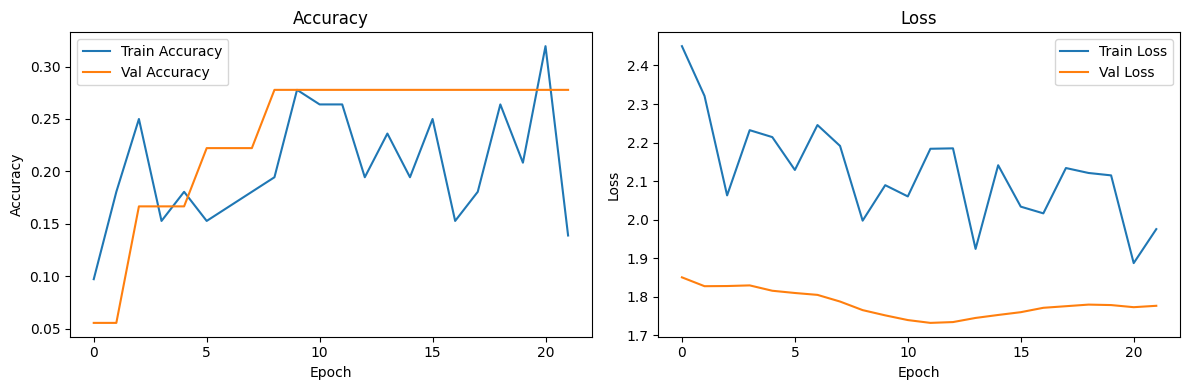

In [26]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_w6.history['accuracy'], label='Train Accuracy')
plt.plot(history_w6.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_w6.history['loss'], label='Train Loss')
plt.plot(history_w6.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

---
# Worksheet 6 — Task 2: Transfer Learning with VGG16

Using pre-trained VGG16 (ImageNet weights). Freeze the base layers, train only the custom classification head.

In [27]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# Step 1: Load VGG16 without top classification layer
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Step 2: Freeze the pre-trained layers
for layer in base_model.layers:
    layer.trainable = False

# Step 3: Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dense(NUM_CLASSES, activation='softmax')(x)

# Step 4: Create the final model
tl_model = Model(inputs=base_model.input, outputs=x)
tl_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │         6,150 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,246,150 (58.16 MB)

 Trainable params: 531,462 (2.03 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [28]:
# Step 5: Compile and train
tl_model.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

tl_checkpoint = ModelCheckpoint(
    filepath='best_vgg16_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)
tl_early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_tl = tl_model.fit(
    train_ds_w6,
    epochs=50,
    validation_data=val_ds_w6,
    callbacks=[tl_checkpoint, tl_early_stop]
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.2940 - loss: 5.8122  
Epoch 1: val_accuracy improved from None to 0.44444, saving model to best_vgg16_model.keras

Epoch 1: finished saving model to best_vgg16_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 35s 11s/step - accuracy: 0.3194 - loss: 5.9804 - val_accuracy: 0.4444 - val_loss: 5.4555
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.8345 - loss: 1.5548  
Epoch 2: val_accuracy improved from 0.44444 to 0.50000, saving model to best_vgg16_model.keras

Epoch 2: finished saving model to best_vgg16_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 41s 11s/step - accuracy: 0.8472 - loss: 1.4147 - val_accuracy: 0.5000 - val_loss: 3.9685
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.8148 - loss: 0.3649  
Epoch 3: val_accuracy improved from 0.50000 to 0.66667, saving model to best_vgg16_model.keras

Epoch 3: finished saving model to best_vgg16_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 37s 13s/step - accuracy: 0.8194 - loss: 0.

In [29]:
tl_loss, tl_accuracy = tl_model.evaluate(test_ds_w6)
print(f"Test Loss: {tl_loss:.4f}")
print(f"Test Accuracy: {tl_accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 0.6000 - loss: 4.3770
Test Loss: 4.3770
Test Accuracy: 0.6000


In [30]:
y_true_tl = []
y_pred_tl = []

for images, labels in test_ds_w6:
    predictions = tl_model.predict(images, verbose=0)
    y_true_tl.extend(labels.numpy())
    y_pred_tl.extend(np.argmax(predictions, axis=1))

print(classification_report(y_true_tl, y_pred_tl, target_names=sorted(classes)))

              precision    recall  f1-score   support

        acai       0.33      1.00      0.50         5
     cupuacu       1.00      0.60      0.75         5
    graviola       1.00      0.60      0.75         5
     guarana       1.00      0.80      0.89         5
     pupunha       0.00      0.00      0.00         5
      tucuma       0.60      0.60      0.60         5

    accuracy                           0.60        30
   macro avg       0.66      0.60      0.58        30
weighted avg       0.66      0.60      0.58        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


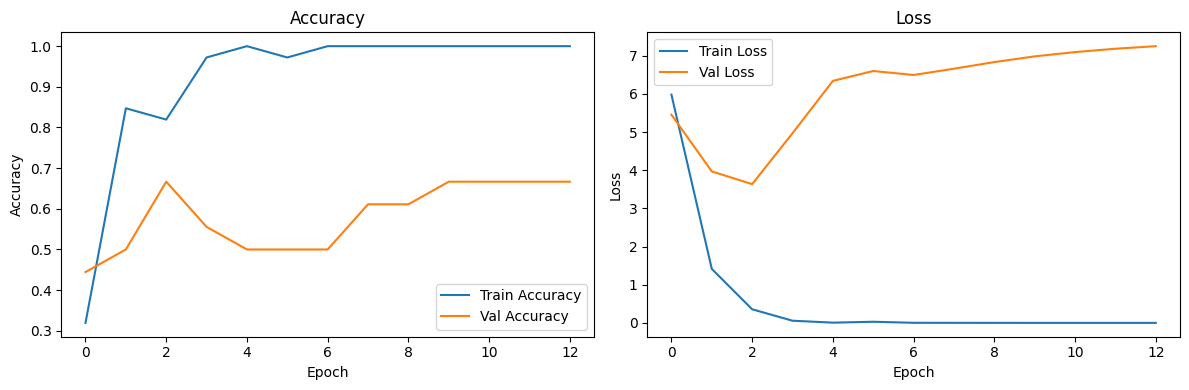

In [31]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_tl.history['accuracy'], label='Train Accuracy')
plt.plot(history_tl.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_tl.history['loss'], label='Train Loss')
plt.plot(history_tl.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()